# Trust Score Clustering Verification

신뢰도 점수(Trust Score)를 기반으로 등급을 나눌 때, **K-Means Clustering**을 사용하여 데이터 분포에 맞는 자연스러운 내추럴 브레이크(Natural Breaks)를 찾는 과정을 검증합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from _00_load_data import load_processed_office_data

# 시각화 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트 (Windows)
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드 및 점수 계산
기존 `_01_feature_engineering.py`의 로직을 그대로 가져와 점수를 계산합니다.

In [2]:
# 데이터 로드
clean_path = r"C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data_nn.csv"
df = pd.read_csv(clean_path)

# 1. 거래완료비율 계산
df["거래완료비율"] = df["거래완료"] / df["총매물수"]
df["거래완료비율"] = df["거래완료비율"].fillna(0)

# 2. 베이지안 파라미터
C = df["거래완료비율"].mean()
m = df["총매물수"].median()
print(f"Global Mean (C): {C:.4f}")
print(f"Threshold (m): {m:.1f}")

# 3. 베이지안 보정 점수
df["베이지안_보정점수"] = (
    (df["총매물수"] / (df["총매물수"] + m)) * df["거래완료비율"] +
    (m / (df["총매물수"] + m)) * C
)

# 4. 신뢰도 점수 (100점 환산)
df["신뢰도점수"] = df["베이지안_보정점수"] * 100

print("점수 계산 완료")
df[["중개사명", "총매물수", "거래완료", "신뢰도점수"]].head()

Global Mean (C): 0.5368
Threshold (m): 91.0
점수 계산 완료


,중개사명,총매물수,거래완료,신뢰도점수
0,태진공인중개사사무소,171,161,80.096127
1,명성공인중개사사무소,81,76,72.588287
2,하늘공인중개사사무소,415,403,89.298785
3,엘공인중개사사무소,164,152,78.765433
4,황금부동산공인중개사사무소,394,380,88.423062


## 2. K-Means Clustering 적용
점수를 1차원 데이터로 보고 3개의 그룹으로 군집화합니다.

In [3]:
# K-Means 적용 (k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(df[["신뢰도점수"]])

# 클러스터 중심점을 기준으로 0, 1, 2 등급 매핑 (점수가 낮은 순서대로 0:하, 1:중, 2:상)
centers = df.groupby("cluster")["신뢰도점수"].mean().sort_values()
print("Cluster Centers (Sorted):", centers.values)

# 매핑 딕셔너리 생성 (Cluster ID -> Grade)
cluster_to_grade = {cluster_id: grade for grade, cluster_id in enumerate(centers.index)}
df["신뢰등급"] = df["cluster"].map(cluster_to_grade)

print("\n--- 등급별 데이터 수 ---")
print(df["신뢰등급"].value_counts().sort_index())

Cluster Centers (Sorted): [35.63150574 55.13663228 81.2520342 ]

--- 등급별 데이터 수 ---
신뢰등급
0     78
1    158
2    103
Name: count, dtype: int64


## 3. 결과 시각화 및 검증
히스토그램을 통해 각 등급이 점수대별로 어떻게 나뉘었는지 확인합니다.

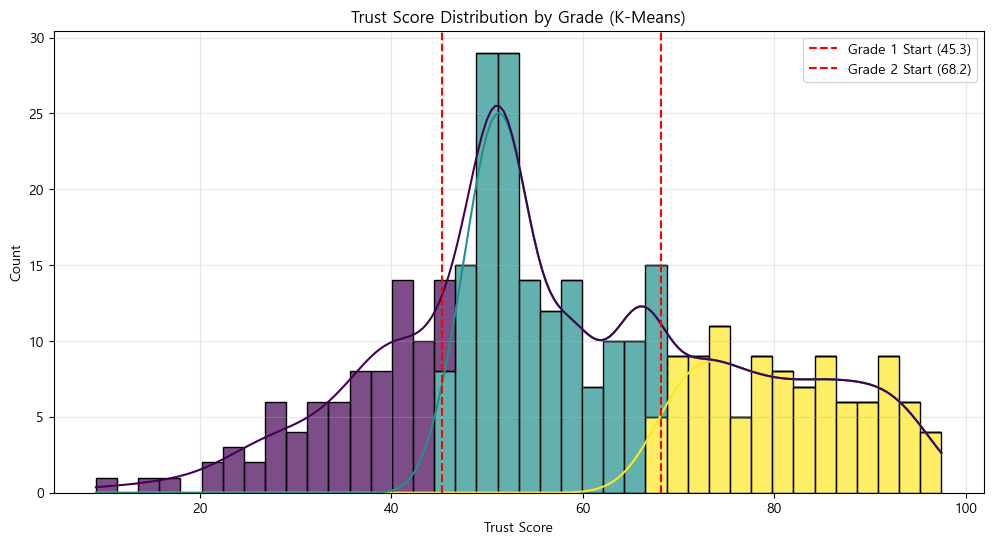

In [4]:
plt.figure(figsize=(12, 6))

# 히스토그램
sns.histplot(data=df, x="신뢰도점수", hue="신뢰등급", palette="viridis", bins=40, kde=True, multiple="stack", alpha=0.7)

# 경계선 표시 (각 등급의 최소값)
for grade in [1, 2]:
    min_score = df[df["신뢰등급"] == grade]["신뢰도점수"].min()
    plt.axvline(min_score, color='red', linestyle='--', label=f'Grade {grade} Start ({min_score:.1f})')

plt.title("Trust Score Distribution by Grade (K-Means)")
plt.xlabel("Trust Score")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. 등급별 통계 확인
각 등급의 점수 범위(Min~Max)를 확인하여 경계가 합리적인지 판단합니다.

In [5]:
stats = df.groupby("신뢰등급")["신뢰도점수"].agg(["count", "min", "max", "mean", "std"])
display(stats)

,count,min,max,mean,std
신뢰등급,,,,,
0,78,9.169654,45.001640,35.631506,7.930724
1,158,45.342313,67.789002,55.136632,6.262322
2,103,68.202349,97.451405,81.252034,8.394428
